# ACS 2024 Income Dataset — Extraction

Builds a **richer income dataset** from the 2024 ACS PUMS (1-Year) via the **Census Data API**
and applies the population/target constraints we settled on. The output is a single clean CSV
(`acs2024v2_income.csv`); **modeling lives in a separate notebook** (`acs2024_currBest_model.ipynb`).

**Why a new extraction:** the existing `new_dataset.csv` (9 features) is signal-limited — every
baseline model converged at R² ≈ 0.30. This pulls **genuinely new predictors** (industry, weeks
worked, geography, nativity, English ability, disability) plus a **clean target population**, the
lever most likely to break past that ceiling.

**Key design decisions:**
- **Year:** single year **2024** (latest released; 2025 PUMS not out yet). One national year is ~3M records — plenty.
- **Target:** `WAGP` (wages/salary) — cleaner than `PINCP` (fewer negatives / no capital-gains noise). Adjusted to constant dollars via `ADJINC`.
- **Population filter:** employed (`ESR` ∈ {1,2}), working age (`AGEP` 18–64), positive wages (`WAGP` > 0), `WKHP` ≥ 1.
- **2024 variable names:** `RELSHIPP` (not the discontinued `RELP`), `WKWN` (not `WKW`). Fallbacks included for older years.

> **Footprint:** we pull from the [Census Data API](https://www.census.gov/data/developers/data-sets/census-microdata-api.html),
> requesting **only the ~22 columns we use** (`get=` parameter) instead of the full ~285-column PUMS
> file — so the transfer is tens of MB. The assembled national frame is cached to `./data` as Parquet
> (one-time). `DENSITY` further subsamples rows to cut RAM/parse cost while staying nationally
> representative. For a quick run, set `STATES=['CA','TX','NY','FL']`.
>
> **One-time setup:** the API requires a **free** key. Get one at <https://api.census.gov/data/key_signup.html>,
> then set it before launching Jupyter — e.g. in PowerShell: `$env:CENSUS_API_KEY = 'your-key'`.

> **v2:** identical pipeline to `acs2024_income_extraction.ipynb`, with the **`PUMA`** (sub-state geography)
> variable added to capture local labor-market / cost-of-living effects.

## Stage 1 — Environment Setup & Library Imports

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## Stage 2 — Data Extraction & Textual Preview

Pull the raw 2024 PUMS person records from the **Census Data API**, requesting only the ~22 columns
we keep (one call per state, concatenated). The assembled frame is cached to `./data` so re-runs skip
the network. Stage 2b then resolves 2024 vs. legacy variable names and selects the working set.

In [2]:
SURVEY_YEAR = '2024'
HORIZON     = '1-Year'       # ACS 1-Year -> API path 'acs1'
STATES      = None           # None = all 50 states + DC. Quick test: ['CA', 'TX', 'NY', 'FL']
DENSITY     = 0.25           # fraction of rows to keep. 1.0 = full ~3.3M; 0.25 ~= 825k, still
                             # nationally representative but ~1/4 the RAM/parse cost. Unlike the
                             # old bulk download, the API only transfers the columns we request
                             # (~22, not ~285), so the network footprint is tens of MB. DENSITY
                             # shrinks the in-memory frame after the (cached) pull.
DATA_DIR    = './data'

# --- Census Data API config -------------------------------------------------
# Free API key required: https://api.census.gov/data/key_signup.html
# Supply it EITHER via the env var CENSUS_API_KEY, OR by pasting it (only the key,
# nothing else) into an untracked file 'census_api_key.txt' next to this notebook.
# The file fallback avoids the common trap where `$env:CENSUS_API_KEY = ...` is set
# in one terminal but the Jupyter kernel (a separate process) never sees it.
def _load_census_key():
    key = os.environ.get('CENSUS_API_KEY')
    if not key:
        for _p in ('census_api_key.txt', os.path.expanduser('~/census_api_key.txt')):
            if os.path.exists(_p):
                _k = open(_p, encoding='utf-8').read().strip()
                if _k:
                    key = _k
                    break
    return key or None

API_KEY  = _load_census_key()
print('API key loaded:', 'yes' if API_KEY else 'NO — set CENSUS_API_KEY or create census_api_key.txt')
API_BASE = f'https://api.census.gov/data/{SURVEY_YEAR}/acs/acs1/pums'

# The ~21 PUMS variables we keep. ST is NOT requested here — the API returns the
# state FIPS in the geography column 'state', which we rename to 'ST' below.
API_VARS = ['WAGP', 'AGEP', 'WKHP', 'WKWN',
            'COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'PUMA', 'RELSHIPP',
            'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS',
            'ESR', 'PWGTP', 'ADJINC']

# Postal -> state FIPS (50 states + DC). PR (72) omitted by default.
STATE_FIPS = {
    'AL': '01', 'AK': '02', 'AZ': '04', 'AR': '05', 'CA': '06', 'CO': '08',
    'CT': '09', 'DE': '10', 'DC': '11', 'FL': '12', 'GA': '13', 'HI': '15',
    'ID': '16', 'IL': '17', 'IN': '18', 'IA': '19', 'KS': '20', 'KY': '21',
    'LA': '22', 'ME': '23', 'MD': '24', 'MA': '25', 'MI': '26', 'MN': '27',
    'MS': '28', 'MO': '29', 'MT': '30', 'NE': '31', 'NV': '32', 'NH': '33',
    'NJ': '34', 'NM': '35', 'NY': '36', 'NC': '37', 'ND': '38', 'OH': '39',
    'OK': '40', 'OR': '41', 'PA': '42', 'RI': '44', 'SC': '45', 'SD': '46',
    'TN': '47', 'TX': '48', 'UT': '49', 'VT': '50', 'VA': '51', 'WA': '53',
    'WV': '54', 'WI': '55', 'WY': '56',
}

def fetch_state(fips):
    """Pull one state's PUMS person records (selected columns) from the Census API."""
    params = {'get': ','.join(API_VARS), 'for': f'state:{fips}'}
    if API_KEY:
        params['key'] = API_KEY
    r = requests.get(API_BASE, params=params, timeout=300)
    r.raise_for_status()
    rows = r.json()                       # [header, *records]
    return pd.DataFrame(rows[1:], columns=rows[0])

os.makedirs(DATA_DIR, exist_ok=True)
tag   = 'all' if STATES is None else '-'.join(STATES)
cache = os.path.join(DATA_DIR, f'acs{SURVEY_YEAR}_pums_api_{tag}_v2.parquet')

if os.path.exists(cache):
    raw = pd.read_parquet(cache)
    print('Loaded cached API extract:', cache)
else:
    if not API_KEY:
        raise RuntimeError(
            "No CENSUS_API_KEY found. Get a free key at "
            "https://api.census.gov/data/key_signup.html, then either set the env var "
            "and restart the kernel:\n    PowerShell:  $env:CENSUS_API_KEY = 'your-key'\n"
            "or paste the key into a file named 'census_api_key.txt' next to this notebook "
            "and re-run this cell (no restart needed).")
    targets = list(STATE_FIPS) if STATES is None else STATES
    frames  = []
    for i, ab in enumerate(targets, 1):
        part = fetch_state(STATE_FIPS[ab])
        frames.append(part)
        print(f"[{i}/{len(targets)}] {ab}: {len(part):,} rows", flush=True)
    raw = pd.concat(frames, ignore_index=True)
    raw.to_parquet(cache, index=False)
    print('Saved API extract cache:', cache)

# API returns the geography column as 'state' (FIPS) -> match the old 'ST' name
raw = raw.rename(columns={'state': 'ST'})
# Values arrive as JSON strings; PUMS fields are numeric codes -> coerce (blanks -> NaN)
for c in raw.columns:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')

# Row subsample (replaces folktables' density=; stays nationally representative)
if DENSITY < 1.0:
    raw = raw.sample(frac=DENSITY, random_state=RANDOM_STATE).reset_index(drop=True)

print("Raw PUMS shape:", raw.shape)

API key loaded: yes


[1/51] AL: 53,710 rows


[2/51] AK: 6,931 rows


[3/51] AZ: 75,745 rows


[4/51] AR: 32,279 rows


...

[49/51] WV: 18,460 rows


[50/51] WI: 62,923 rows


[51/51] WY: 6,199 rows


Saved API extract cache: ./data\acs2024_pums_api_all_v2.parquet


Raw PUMS shape: (855722, 23)


In [3]:
# Resolve variable names that changed across ACS years
def pick(df, *names):
    """Return the first column name present in df (handles year-to-year renames)."""
    return next((n for n in names if n in df.columns), None)

REL_COL = pick(raw, 'RELSHIPP', 'RELP')      # relationship: RELSHIPP (2019+), RELP (<=2018)
WKW_COL = pick(raw, 'WKWN', 'WKW')           # weeks worked: WKWN continuous (2019+), WKW recode

TARGET       = 'WAGP'                          # wages/salary income
CONTINUOUS   = ['AGEP', 'WKHP', WKW_COL]
CATEGORICAL  = ['COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'PUMA', REL_COL,
                'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST']
FILTER_COLS  = ['ESR', 'PWGTP', 'ADJINC']

keep = CONTINUOUS + CATEGORICAL + [TARGET] + FILTER_COLS
keep = [c for c in keep if c is not None and c in raw.columns]
df = raw[keep].copy()

print("Relationship column:", REL_COL, "| Weeks-worked column:", WKW_COL)
print("Selected columns:", list(df.columns))
print("Shape:", df.shape)

Relationship column: RELSHIPP | Weeks-worked column: WKWN
Selected columns: ['AGEP', 'WKHP', 'WKWN', 'COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'PUMA', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST', 'WAGP', 'ESR', 'PWGTP', 'ADJINC']
Shape: (855722, 23)


In [4]:
print(df.head(), "\n")
print(df.info(), "\n")
print(df[TARGET].describe(), "\n")
print("Missing values per column:\n", df.isna().sum())

   AGEP  WKHP  WKWN  COW  SCHL  MAR    OCCP    INDP  POBP   PUMA  RELSHIPP  SEX  RAC1P  HISP  CIT  NATIVITY  ENG  DIS  ST    WAGP  ESR  PWGTP   ADJINC
0    27    55    52    1    16    5  9620.0  6170.0    48   5906        20    1      9    24    1         1    1    2  48   54000    1     93  1.01525
1    27    40    52    7    15    5  4251.0  7770.0     4   4502        22    1      1     1    1         1    0    2  48   40000    1     72  1.01525
2    41    40    52    3    20    3  3655.0  9480.0    26   3006        20    2      9     1    1         1    0    1  26   34000    1    102  1.01525
3    73     0     0    0    16    1     NaN     NaN    40  20801        21    2      1     1    1         1    0    2  40       0    6    147  1.01525
4    65    35    52    2    23    1  2100.0  7270.0    36   2001        20    1      1     1    1         1    0    1  36  133000    1     71  1.01525 

<class 'pandas.DataFrame'>
RangeIndex: 855722 entries, 0 to 855721
Data columns (total 23 co

## Stage 3 — Data Cleaning, Filtering & Target Construction

1. **Inflation adjustment** — scale income by `ADJINC` to constant 2024 dollars.
2. **Population filter** — employed, working-age adults with positive wages (this is the high-impact step: it removes the retirees/teens/zero-earners that inflate error).
3. **Missing values** — sentinel-fill categoricals; median-fill continuous.
4. **Types** — categoricals to integer codes for native categorical handling downstream.

In [5]:
# 1) Adjust income to constant dollars (ADJINC is stored x1e6)
if 'ADJINC' in df.columns:
    df[TARGET] = df[TARGET] * (df['ADJINC'] / 1e6)

# 2) Population filter
before = len(df)
df = df[df['ESR'].isin([1, 2])]          # civilian employed (at work / with job)
df = df[(df['AGEP'] >= 18) & (df['AGEP'] <= 64)]
df = df[df['WKHP'] >= 1]
df = df[df[TARGET] > 0]
print(f"Population filter: {before:,} -> {len(df):,} rows ({len(df)/before*100:.1f}% kept)")

# Drop helper columns no longer needed as features
df = df.drop(columns=[c for c in ['ESR', 'PWGTP', 'ADJINC'] if c in df.columns])

Population filter: 855,722 -> 339,848 rows (39.7% kept)


In [6]:
# 3) Missing values
for c in CATEGORICAL:
    if c in df.columns:
        df[c] = df[c].fillna(-1)            # -1 = 'not applicable' as its own category
for c in CONTINUOUS:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())

# 4) Categoricals -> integer codes (required by native categorical learners)
for c in CATEGORICAL:
    if c in df.columns:
        df[c] = df[c].astype(int)

print("Remaining missing values:", int(df.isna().sum().sum()))
print("Clean shape:", df.shape)

Remaining missing values: 0
Clean shape: (339848, 20)


## Stage 4 — Graphical Data Exploration (EDA)

A quick look at the cleaned dataset. The raw wage distribution is heavily right-skewed — worth
knowing when a model later chooses to fit `log1p(WAGP)`.

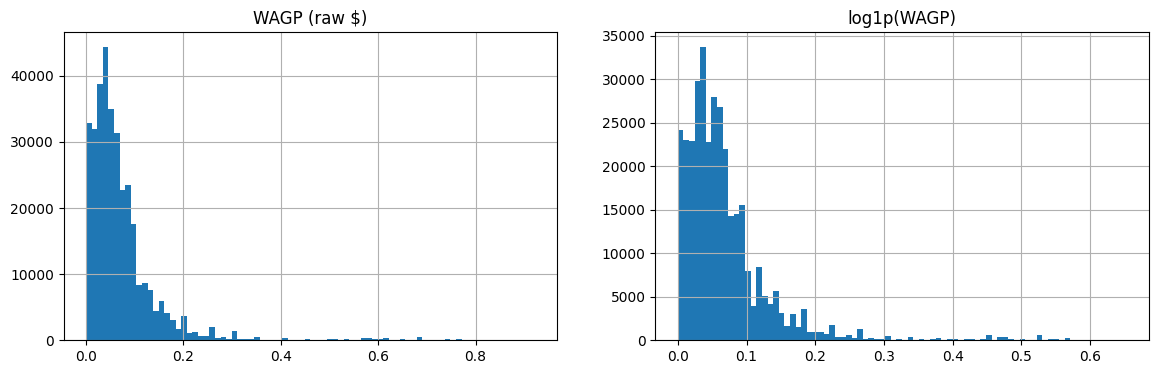

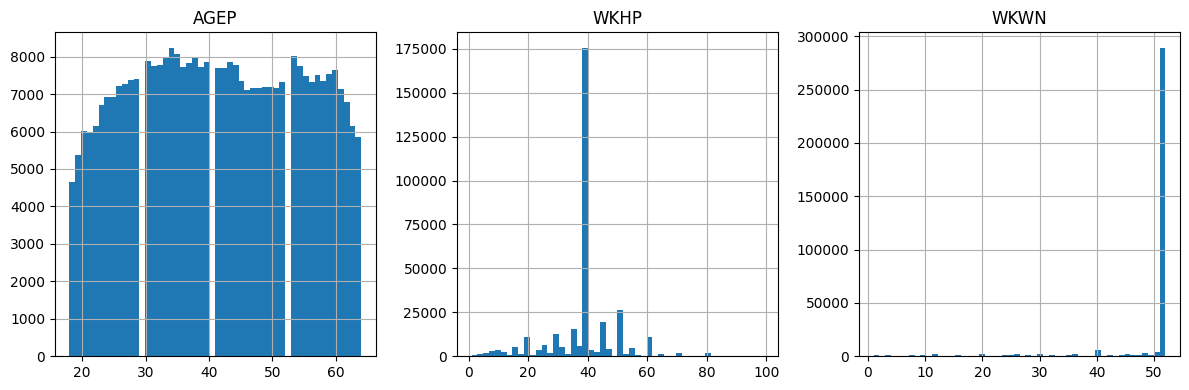

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df[TARGET].hist(bins=80, ax=ax[0]); ax[0].set_title('WAGP (raw $)')
np.log1p(df[TARGET]).hist(bins=80, ax=ax[1]); ax[1].set_title('log1p(WAGP)')
plt.show()

# Continuous features
df[CONTINUOUS].hist(bins=50, figsize=(12, 4), layout=(1, 3))
plt.tight_layout(); plt.show()

## Stage 5 — Save Dataset

Persist the cleaned extract to `acs2024v2_income.csv` for reuse / comparison against `new_dataset.csv`.
Modeling is done in `acs2024_currBest_model.ipynb`, which reads this file.

In [8]:
FEATURES = [c for c in (CONTINUOUS + CATEGORICAL) if c in df.columns]
out_cols = FEATURES + [TARGET]

df[out_cols].to_csv('acs2024v2_income.csv', index=False)
print('Saved acs2024v2_income.csv', df[out_cols].shape)
print('Columns:', out_cols)

Saved acs2024v2_income.csv (339848, 20)
Columns: ['AGEP', 'WKHP', 'WKWN', 'COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'PUMA', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST', 'WAGP']
